# Isolation Forest — Anomaly Detection

The Isolation Forest is an **unsupervised anomaly detection** algorithm proposed by Liu, Ting, and Zhou (2008). Its guiding principle is radically different from traditional approaches: instead of modeling normal behavior to deduce anomalies by deviation, it **directly isolates** anomalies by exploiting two structural properties that distinguish them from normal points:

* **Rarity**: anomalies are few and far between in the data.
* **Difference**: they are located far away from dense regions.

These two properties make anomalies **easier to isolate** in a random partitioning tree: they require fewer cuts to be separated from any other point. This ease of isolation is measured by the **path length** $h(\mathbf{x})$ in the tree — the shorter it is, the more suspicious the point.

## 1. Key Concepts

### Ensemble Structure

The algorithm constructs an ensemble of $T$ random binary trees called *isolation trees* (iTrees). Each iTree is trained on a random subsample $\mathcal{S}$ of size $\psi$ drawn without replacement from $\mathcal{D}$. The maximum depth of each tree is capped at:

$$\ell = \lceil \log_2 \psi \rceil$$

This ceiling is sufficient to isolate any point within a sample of size $\psi$, ensuring that the trees remain lightweight and fast.

### Path Length and Leaf Correction

For a point $\mathbf{x}$, the **path length** $h(\mathbf{x})$ in an iTree is the number of edges traversed from the root to the terminating leaf. When the depth limit is reached before complete isolation, the leaf still contains $n$ points. We then correct the path length using the term:

$$c(n) = 2\left(\ln(n-1) + \gamma\right) - \frac{2(n-1)}{n}$$

where $\gamma \approx 0.5772$ is the Euler–Mascheroni constant. This term $c(n)$ represents the expected path length of an unsuccessful search in a random BST with $n$ nodes — which is the average number of additional cuts that would have been required to finish isolation.

### Anomaly Score

The average path length $\mathbb{E}[h(\mathbf{x})]$ across all trees is normalized by $c(\psi)$ to produce a score within $(0, 1]$:

$$s(\mathbf{x},\, \psi) = 2^{-\,\dfrac{\mathbb{E}[h(\mathbf{x})]}{c(\psi)}}$$

| Score | Interpretation |
| --- | --- |
| $s \to 1$ | Highly likely to be an **anomaly** — very short path |
| $s \approx 0.5$ | **Ambiguous** signal — no clear conclusion |
| $s \to 0$ | Clearly **normal** point — very long path |
#

<img src="../assets/imgs/isolation/isolation.webp" alt="Illustration Isolation Forest"/>

Figure 2 — An anomalous point is isolated in 1 cut. Figure 3: a normal point requires 4 cuts. Source: Liu et al. (2008).

## 2. Isolation Mechanism

### Building an iTree

At each internal node, the tree performs a **random cut**:

1. Uniformly chooses a split feature $q \in \{1, \dots, d\}$.
2. Uniformly chooses a split value $p \in [\min_q(\mathcal{S}),\, \max_q(\mathcal{S})]$.
3. Sends points satisfying $x_q < p$ to the left child, and the remaining points to the right child.

The recursion stops when any of the following conditions are met:

* The depth limit $\ell$ is reached.
* The node contains only a single point ($n \leq 1$).
* All points in the node are identical (`np.all(X == X[0])`).

### Evaluation and Path Length

To evaluate a point $\mathbf{x}$, it is passed down the tree following the splits — at each internal node, if $x_q < p$ it goes left, otherwise right — until it reaches a leaf node. The reached depth $e$ is then increased by the leaf correction term $c(n_{\text{leaf}})$:

$$h(\mathbf{x}) = e + c(n_{\text{leaf}})$$

### Why a Small $\psi$ Suffices

Counter-intuitively, using a very small subsample ($\psi = 256$) is not only sufficient but often **optimal**. Small samples accentuate the structural difference between dense regions (normal points) and sparse regions (anomalies), making the isolation process more discriminative. Furthermore, since each tree is trained on only $\psi$ points, the overall complexity remains bounded by $\mathcal{O}(T \cdot \psi \cdot \log \psi)$ independently of $N$.

## 3. Pseudo-algorithm

The implementation breaks down into three distinct functional blocks, directly reflecting the structure of the code.

### Normalization $c(n)$

$$c(n) = \begin{cases} 0 & n \leq 1 \\ 1 & n = 2 \\ 2(\ln(n-1) + \gamma) - \dfrac{2(n-1)}{n} & n > 2 \end{cases}$$

### Building an iTree — `build_itree(X, depth, ℓ)`

```
1.  if depth ≥ ℓ  or  |X| ≤ 1  or  all points are identical:
2.      return Leaf(size = |X|)
3.  q  ← random integer in {0, …, d−1}
4.  p  ← random float in [min(X[:,q]),  max(X[:,q])]
5.  X_left   ← { x ∈ X | x[q] < p }
6.  X_right  ← X \ X_left
7.  return Node(axis=q, threshold=p,
                   left = build_itree(X_left,  depth+1, ℓ),
                   right = build_itree(X_right,  depth+1, ℓ))

```

### Path Length — `path_length(x, node, depth)`

```
1.  if node is a leaf:
2.      return depth + c(node.size)
3.  if x[node.axis] < node.threshold:
4.      return path_length(x, node.left,  depth + 1)
5.  else:
6.      return path_length(x, node.right, depth + 1)

```

### Training and Scoring — `IsolationForest`

```
fit(X):
    ℓ ← ⌈log₂(ψ)⌉
    for t = 1 to T:
        S ← random subsample of size ψ from X (without replacement)
        trees[t] ← build_itree(S, 0, ℓ)
    threshold ← percentile(anomaly_score(X), 100×(1 − contamination))

anomaly_score(X):
    for each x ∈ X:
        E_h ← average of path_length(x, tree, 0) across all trees
        s(x) ← 2^(−E_h / c(ψ))
    return s

predict(X):
    return (anomaly_score(X) ≥ threshold).astype(int)
    # 1 = anomaly,  0 = normal

```

## 4. Implementation

### Importing the Local Library

In [1]:
import sys
sys.path.append(
    r"D:\Nouveau dossier\AIOT\Cours-Machine-learning\Ifri-mini-ml-lib\miniml"
    r"\ifri_mini_ml_lib\ifri_mini_ml_lib"
)

### Synthetic Data

We generate a controlled 2D dataset: a dense Gaussian cluster of normal points, to which we manually add anomalies scattered across the space. The ground truth labels allow us to quantitatively evaluate both implementations.

The label convention adopted here is: **0 = normal, 1 = anomaly**.

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Points normaux : cluster gaussien dense centré en (0, 0)
X_normal  = rng.normal(loc=0.0, scale=0.5, size=(300, 2))

# Anomalies : dispersées uniformément loin du cluster
X_anomaly = rng.uniform(low=-5.0, high=5.0, size=(30, 2))
mask      = np.linalg.norm(X_anomaly, axis=1) > 2.0   # au moins à distance 2 du centre
X_anomaly = X_anomaly[mask][:15]

# Assemblage et étiquettes de vérité terrain
X      = np.vstack([X_normal, X_anomaly])
y_true = np.array([0] * len(X_normal) + [1] * len(X_anomaly))

contamination_rate = len(X_anomaly) / len(X)

print(f"Dataset: {len(X_normal)} normal points + {len(X_anomaly)} anomalies")
print(f"Real contamination rate: {contamination_rate:.3f}")

Dataset: 300 normal points + 15 anomalies
Real contamination rate: 0.048


In [3]:
pd.DataFrame(X, columns=['Feature 1', 'Feature 2']).describe().round(3)

,Feature 1,Feature 2
count,315.000,315.000
mean,-0.008,0.002
std,0.842,0.852
min,-4.704,-4.955
25%,-0.344,-0.402
50%,0.006,-0.020
75%,0.337,0.310
max,3.956,4.247


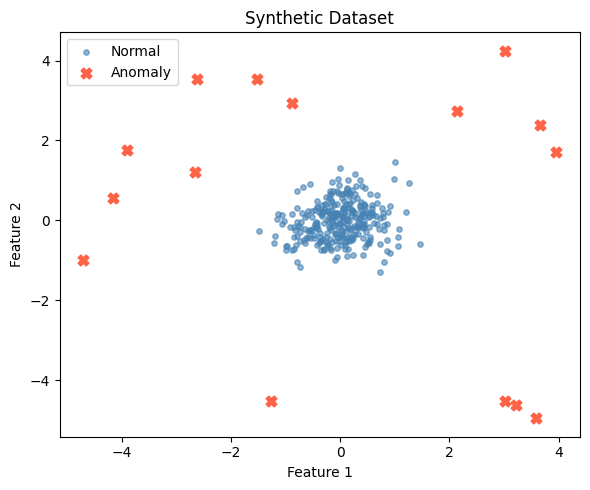

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_normal[:, 0],  X_normal[:, 1],  c='steelblue', s=15, alpha=0.6, label='Normal')
ax.scatter(X_anomaly[:, 0], X_anomaly[:, 1], c='tomato',    s=60, marker='X', label='Anomaly')
ax.set_title('Synthetic Dataset')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
plt.tight_layout()
plt.show()

### Avec Scikit-learn

In [5]:
from sklearn.ensemble import IsolationForest as SklearnIF

start_sk = time.perf_counter()
clf = SklearnIF(n_estimators=100, max_samples=256,
                contamination=contamination_rate, random_state=42)
clf.fit(X)
end_sk = time.perf_counter()

# sklearn : +1 = normal, -1 = anomaly →  converting in 0/1
y_pred_sk = (clf.predict(X) == -1).astype(int)

### Avec ifri-mini-ml-lib

In [6]:
from anomalies_detection.isolation_forest import IsolationForest

start_if = time.perf_counter()
iso = IsolationForest(n_trees=100, sample_size=256, contamination=contamination_rate)
iso.fit(X)
end_if = time.perf_counter()

# Our implementation : 1 = anomaly, 0 = normal
y_pred_if = iso.predict(X)

ModuleNotFoundError: No module named 'anomalies_detection.isolation_forest'

In [ ]:
from metrics.classification import accuracy, precision, recall, f1_score


def evaluate(y_true, y_pred, elapsed):
    """Metrics centered on the anomaly class (positive = 1)."""
    return {
        'Accuracy' : round(accuracy(y_true, y_pred), 4),
        'Precision': round(precision(y_true, y_pred), 4),
        'Recall'   : round(recall(y_true, y_pred), 4),
        'F1 Score' : round(f1_score(y_true, y_pred), 4),
        'Time (s)' : round(elapsed, 4),
    }

pd.DataFrame({
    'Scikit-learn'    : evaluate(y_true, y_pred_sk, end_sk - start_sk),
    'ifri-mini-ml-lib': evaluate(y_true, y_pred_if, end_if - start_if),
})

,Scikit-learn,ifri-mini-ml-lib
Accuracy,1.0000,1.0000
Precision,1.0000,1.0000
Recall,1.0000,1.0000
F1 Score,1.0000,1.0000
Time (s),0.3982,0.8392


### Visualisation des scores et des prédictions

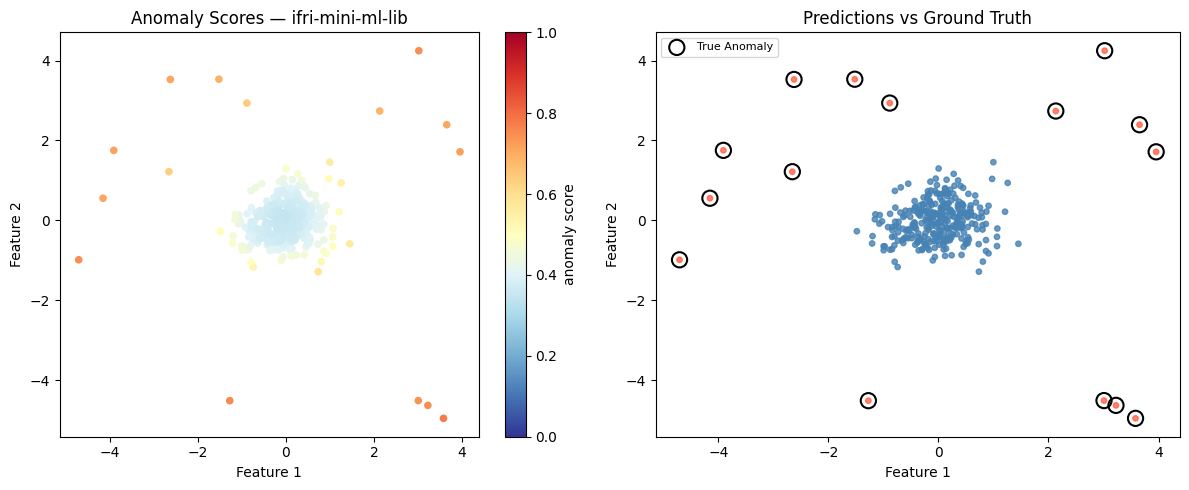

In [ ]:
scores_if = iso.anomaly_score(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Anomaly Scores map ───────────────────────────────────────────────
sc = axes[0].scatter(X[:, 0], X[:, 1], c=scores_if,
                     cmap='RdYlBu_r', s=20, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[0], label="anomaly score")
axes[0].set_title("Anomaly Scores — ifri-mini-ml-lib")
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# ── Predictions vs Ground Truth ────────────────────────────────────────────
colors = np.where(y_pred_if == 1, 'tomato', 'steelblue')
axes[1].scatter(X[:, 0], X[:, 1], c=colors, s=15, alpha=0.8)
# Highlight true anomalies with a distinct marker to recover the false negatives (FN).
axes[1].scatter(X_anomaly[:, 0], X_anomaly[:, 1],
                edgecolors='black', facecolors='none',
                s=120, linewidths=1.5, label='True Anomaly')
axes[1].legend(fontsize=8)
axes[1].set_title('Predictions vs Ground Truth')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

## 5. Démonstration interactive

In [ ]:
from ipywidgets import interact, IntSlider, FloatSlider

def demo_isolation_forest(n_trees, sample_size, contamination):
    model = IsolationForest(n_trees=n_trees, sample_size=sample_size,
                            contamination=contamination)
    model.fit(X)
    scores = model.anomaly_score(X)
    y_pred = model.predict(X)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sc = axes[0].scatter(X[:, 0], X[:, 1], c=scores,
                         cmap='RdYlBu_r', s=20, vmin=0, vmax=1)
    plt.colorbar(sc, ax=axes[0], label="Anomaly Score")
    axes[0].set_title(f'Scores  [T={n_trees}, ψ={sample_size}]')
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')

    colors = np.where(y_pred == 1, 'tomato', 'steelblue')
    axes[1].scatter(X[:, 0], X[:, 1], c=colors, s=15, alpha=0.8)
    axes[1].scatter(X_anomaly[:, 0], X_anomaly[:, 1],
                    edgecolors='black', facecolors='none',
                    s=120, linewidths=1.5, label='True Anomaly')
    axes[1].legend(fontsize=8)
    axes[1].set_title(f'Predictions  [contamination={contamination:.2f}]')
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')

    plt.tight_layout()
    plt.show()

    # Summary of metrics under the plot
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"Threshold : {model.threshold:.4f}  │  "
          f"Precision : {prec:.2f}  │  Recall : {rec:.2f}  │  F1 : {f1:.2f}")


interact(
    demo_isolation_forest,
    n_trees     = IntSlider(min=10,   max=200, step=10,  value=100,
                            description='Trees (T):'),
    sample_size = IntSlider(min=32,   max=512, step=32,  value=256,
                            description='ψ:'),
    contamination = FloatSlider(min=0.01, max=0.4, step=0.01,
                                value=round(contamination_rate, 2),
                                readout_format='.2f',
                                description='Contamination:'),
)

interactive(children=(IntSlider(value=100, description='Trees (T):', max=200, min=10, step=10), IntSlider(valu…

<function __main__.demo_isolation_forest(n_trees, sample_size, contamination)>

Some experiments to conduct with the sliders:

* **Reducing $T$ to 10**: the scores become noisy — normal points near the edge of the cluster may flip labels from one run to another, showing that the estimator's variance is high when there are few trees.
* **Increasing $\psi$ to 512**: the decision boundary smoothens, but the training time increases. Below 128, you can observe the opposite effect: trees that are too sparse in data.
* **Underestimating the contamination** (e.g., 0.01): the threshold increases, making the model too conservative → false negatives on anomalies.
* **Overestimating the contamination** (e.g., 0.30): the threshold decreases, capturing normal points → false positives.

## 6. Real-World Applications

The speed, scalability in $\mathcal{O}(T \cdot \psi \log \psi)$, and lack of distance metric constraints make the Isolation Forest algorithm particularly well-suited for high-volume or high-dimensional contexts.

**Cybersecurity and Intrusion Detection** — System call sequences, network traffic, or authentication logs can be continuously monitored. Unusual behavior (such as port scanning or logging in from an unknown location) naturally stands out with a short path length in the forest.

**Finance and Fraud Detection** — Bank transactions or stock market order flows contain rare but costly anomalies. Isolation Forest excels here because the datasets are massive and unlabeled, and fraudulent patterns constantly evolve — making supervised training difficult.

**Industrial Predictive Maintenance** — Machine sensors (vibrations, temperature, current) produce multivariate time series. The algorithm can detect unusual combinations of values preceding a breakdown long before any fixed threshold is triggered.

**Data Pipeline Quality Control** — Within machine learning pipelines, Isolation Forest can automatically identify corrupted or mislabeled instances in a training dataset before they degrade a production model's performance.

## 7. Limitations and Precautions

**Masking Effect** — If anomalies group together into dense clusters, their path length increases and their score shifts closer to that of normal points. Reducing $\psi$ mitigates this problem by lowering the probability that multiple anomalous points coexist within the same subsample.

**Swamping Effect** — A normal cluster that is isolated from the rest of the data might receive high anomaly scores simply because it is far from the main data mass. The model confuses geographic isolation with actual anomaly status.

**Sensitivity to Contamination Rate** — The decision threshold is directly tuned based on this parameter. An incorrect estimation shifts the entire system. When the true contamination rate is unknown, it is better to work with the continuous outputs of `anomaly_score()` and select the threshold using external validation.

**Python Recursion** — `build_itree` and `path_length` are recursive. With very large values of $\psi$ or data containing many constant columns, the Python stack can saturate (`RecursionError`). An iterative implementation utilizing an explicit stack would be more robust for production environments.

**No Native Explainability** — The model does not directly output which features contributed to a point's anomaly score. External tools like SHAP's `TreeExplainer` are required for interpretation, which can be a constraint in regulated industries.

## 8. References

- Liu, F.T., Ting, K.M. et Zhou, Z.H. (2008). *Isolation Forest*. IEEE 8th International Conference on Data Mining (ICDM). https://doi.org/10.1109/ICDM.2008.17
- Liu, F.T., Ting, K.M. et Zhou, Z.H. (2012). *Isolation-Based Anomaly Detection*. ACM Transactions on Knowledge Discovery from Data (TKDD). https://doi.org/10.1145/2133360.2133363
- Documentation Scikit-learn — Isolation Forest. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
- Chandola, V., Banerjee, A. et Kumar, V. (2009). *Anomaly Detection: A Survey*. ACM Computing Surveys. https://doi.org/10.1145/1541880.1541882